# Logistic Regression CPCV

This notebook does one thing: test L2, L1, and Elastic Net logistic regression models with Combinatorial Purged Cross Validation.

The flow is intentionally simple:
1. Load clean features and saved triple-barrier labels.
2. Merge one label file with its matching feature file.
3. Split the rows into chronological CPCV blocks.
4. Purge overlapping event windows and apply the `num_days` embargo.
5. Fit logistic models fold by fold.
6. Rank the model/config combinations by CPCV AUC.


## 0. Imports

Keep imports separate so the rest of the notebook reads like normal Python steps.


In [1]:
from __future__ import annotations

import itertools
import os
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", os.path.join(tempfile.gettempdir(), "matplotlib"))

import numpy as np
import pandas as pd
import matplotlib

try:
    ipython = get_ipython()
except NameError:
    ipython = None

IN_NOTEBOOK = ipython is not None
if IN_NOTEBOOK:
    ipython.run_line_magic("matplotlib", "inline")
else:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, brier_score_loss, f1_score, log_loss, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)
pd.set_option("display.max_rows", 100)


## 1. Settings

Change these values first. Smoke mode runs one instrument and one barrier config so the notebook is quick to debug.


In [2]:
RUN_FULL_GRID = False
SAVE_OUTPUTS = False

RANDOM_STATE = 42
PROBA_THRESHOLD = 0.50
TRAIN_END_DATE = pd.Timestamp("2022-01-01")

SMOKE_INSTRUMENTS = ["cl1s"]
FULL_INSTRUMENTS = ["cl1s", "ho1s", "rb1s", "ng1s"]
SMOKE_CONFIG_NAMES = ["ewma_10d_tp2_sl2"]

INSTRUMENTS = FULL_INSTRUMENTS if RUN_FULL_GRID else SMOKE_INSTRUMENTS
C_VALUES = [0.01, 0.1, 1.0, 10.0] if RUN_FULL_GRID else [0.1, 1.0]
L1_RATIOS = [0.25, 0.5, 0.75] if RUN_FULL_GRID else [0.5]

CPCV_SETTINGS = {
    "cl1s": {"n_groups": 6, "k_test_groups": 2},
    "rb1s": {"n_groups": 6, "k_test_groups": 2},
    "ho1s": {"n_groups": 4, "k_test_groups": 1},
    "ng1s": {"n_groups": 4, "k_test_groups": 1},
}

FEATURE_CLIP_LOWER = 0.01
FEATURE_CLIP_UPPER = 0.99
FEATURE_ABS_CAP = 1_000_000.0

print("Run full grid:", RUN_FULL_GRID)
print("Instruments:", INSTRUMENTS)
print("C values:", C_VALUES)
print("Elastic Net l1 ratios:", L1_RATIOS)


Run full grid: False
Instruments: ['cl1s']
C values: [0.1, 1.0]
Elastic Net l1 ratios: [0.5]


## 2. Paths And Columns To Exclude

The target and triple-barrier result columns cannot be model features. Raw OHLCV levels are also removed because they are non-stationary level features.


In [3]:
def find_project_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "features").exists():
            return candidate
    raise FileNotFoundError("Could not find project root with data/features")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
CLEAN_DIR = PROJECT_ROOT / "data" / "features" / "clean_feature_set"
TB_DIR = PROJECT_ROOT / "data" / "features" / "triple_barrier"
TB_SUMMARY_PATH = TB_DIR / "triple_barrier_config_summary.csv"
OUTPUT_DIR = PROJECT_ROOT / "data" / "models" / "logistic_cpcv"

TOP5_RESULTS_PATH = PROJECT_ROOT / "results" / "linear_regression.csv"
LOGISTIC_RESULTS_PATH = PROJECT_ROOT / "results" / "logistic_regression.csv"

LEAKAGE_COLUMNS = {
    "training_end", "vol", "tp", "sl", "timeout_date", "timeout_close",
    "touch_date", "touch_price", "touched_barrier", "triple_barrier_label", "metalabel",
    "volatility_method", "ewma_span", "volatility_window", "num_days", "take_profit_mult",
    "stop_loss_mult", "holding_period_days", "raw_touch_return", "signed_touch_return",
}
RAW_LEVEL_COLUMNS = {"open", "high", "low", "close", "volume", "open_interest"}
EXCLUDED_FEATURE_COLUMNS = LEAKAGE_COLUMNS | RAW_LEVEL_COLUMNS


## 3. Load Clean Feature Files

Each instrument has one clean feature file. These are the candidate predictors before we remove leakage columns.


In [4]:
clean_features = {}
feature_file_summary = []

for instrument in INSTRUMENTS:
    path = CLEAN_DIR / f"{instrument}_clean_feature_set.csv"
    assert path.exists(), f"Missing clean feature file: {path}"

    df = pd.read_csv(path, parse_dates=["date"])
    df = df.sort_values("date").reset_index(drop=True)

    assert df["instrument"].eq(instrument).all()
    assert df["date"].duplicated().sum() == 0

    check_cols = [c for c in df.columns if c not in {"date", "instrument", "primary_signal"}]
    assert df[check_cols].isna().sum().sum() == 0, f"Missing feature values remain in {path}"

    clean_features[instrument] = df.drop(columns=["primary_signal"], errors="ignore")
    feature_file_summary.append({
        "instrument": instrument,
        "clean_rows": len(df),
        "clean_columns": df.shape[1],
    })

display(pd.DataFrame(feature_file_summary))


,instrument,clean_rows,clean_columns
0,cl1s,626,146


## 4. Load Triple-Barrier Label Files

The config summary tells us which saved triple-barrier CSVs exist. We also show the metalabel class distribution before modelling.


In [5]:
label_files = pd.read_csv(TB_SUMMARY_PATH)
label_files = label_files[label_files["instrument"].isin(INSTRUMENTS)].copy()

if not RUN_FULL_GRID:
    label_files = label_files[label_files["config_name"].isin(SMOKE_CONFIG_NAMES)].copy()

label_files["label_path"] = label_files["output_path"].map(
    lambda p: str(Path(p) if Path(p).exists() else TB_DIR / Path(p).name)
)

missing = [p for p in label_files["label_path"] if not Path(p).exists()]
assert not missing, f"Missing label files: {missing[:5]}"
assert not label_files.empty, "No label files selected."

label_files["metalabel_0_count"] = label_files["metalabel_0_count"].astype(int)
label_files["metalabel_1_count"] = label_files["metalabel_1_count"].astype(int)
label_files["metalabel_0_rate"] = label_files["metalabel_0_count"] / label_files["rows"]
label_files["metalabel_1_rate"] = label_files["metalabel_1_count"] / label_files["rows"]

display(
    label_files[
        [
            "instrument", "config_name", "rows", "metalabel_0_count", "metalabel_1_count",
            "metalabel_0_rate", "metalabel_1_rate", "num_days", "label_path",
        ]
    ].head(20)
)


,instrument,config_name,rows,metalabel_0_count,metalabel_1_count,metalabel_0_rate,metalabel_1_rate,num_days,label_path
0,cl1s,ewma_10d_tp2_sl2,324,201,123,0.62037,0.37963,10,/Users/akshatg/Desktop/Imperial/Assessments/Te...


## 5. Build One Modelling Table

For one triple-barrier file:
- read the labels,
- merge labels with clean features on `date` and `instrument`,
- keep only pre-2022 rows,
- use `metalabel` as the target,
- use `num_days` as the embargo length.


In [6]:
def read_labels(label_path):
    columns = pd.read_csv(label_path, nrows=0).columns
    date_cols = [c for c in ["date", "training_end", "timeout_date", "touch_date"] if c in columns]
    labels = pd.read_csv(label_path, parse_dates=date_cols)
    return labels.sort_values("date").reset_index(drop=True)


def make_model_data(label_row):
    labels = read_labels(label_row["label_path"])
    features = clean_features[label_row["instrument"]]

    labels = labels.drop(columns=["close"], errors="ignore")
    data = labels.merge(features, on=["date", "instrument"], how="inner")
    data = data.sort_values("date").reset_index(drop=True)

    data = data[data["date"] < TRAIN_END_DATE].copy()
    data = data[(data["metalabel"].isin([0, 1])) & (data["primary_signal"] != 0)].copy()
    data = data.sort_values("date").reset_index(drop=True)

    assert not data.empty, f"No merged rows for {label_row['instrument']} {label_row['config_name']}"
    assert data["metalabel"].nunique() == 2, "Need both metalabel classes."
    assert data["num_days"].nunique() == 1, "One label file should have one num_days value."

    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    feature_cols = [c for c in numeric_cols if c not in EXCLUDED_FEATURE_COLUMNS]
    assert feature_cols, "No numeric features available."
    assert not set(feature_cols).intersection(EXCLUDED_FEATURE_COLUMNS)

    data[feature_cols] = data[feature_cols].replace([np.inf, -np.inf], np.nan)
    embargo_observations = int(data["num_days"].iloc[0])

    return data, feature_cols, embargo_observations


## 6. CPCV Helpers

CPCV is easiest to understand in two steps:
1. Split rows into equal chronological blocks.
2. For each model split, choose combinations of blocks as the test set.

The training set starts as all non-test blocks. Then we remove rows whose event windows overlap the test window, and we remove rows inside the `num_days` embargo after the test block.


In [7]:
def date_after_n_observations(dates, end_date, n):
    unique_dates = pd.Series(pd.to_datetime(dates).sort_values().unique())
    first_after_end = unique_dates.searchsorted(pd.Timestamp(end_date), side="right")

    if first_after_end >= len(unique_dates):
        return pd.Timestamp(end_date)

    end_position = min(len(unique_dates) - 1, first_after_end + n - 1)
    return pd.Timestamp(unique_dates.iloc[end_position])


def make_cpcv_blocks(data, instrument):
    n_groups = CPCV_SETTINGS[instrument]["n_groups"]
    row_numbers = np.arange(len(data))
    blocks = [block.astype(int) for block in np.array_split(row_numbers, n_groups) if len(block) > 0]

    sizes = [len(block) for block in blocks]
    assert max(sizes) - min(sizes) <= 1, "CPCV blocks should be equal-sized apart from one row."
    return blocks


def make_cpcv_splits(data, instrument, embargo_observations):
    blocks = make_cpcv_blocks(data, instrument)
    k_test_groups = CPCV_SETTINGS[instrument]["k_test_groups"]
    splits = []

    test_block_combinations = itertools.combinations(range(len(blocks)), k_test_groups)

    for split_id, test_block_ids in enumerate(test_block_combinations):
        test_idx = np.concatenate([blocks[block_id] for block_id in test_block_ids])
        train_mask = np.ones(len(data), dtype=bool)
        train_mask[test_idx] = False

        for block_id in test_block_ids:
            block_idx = blocks[block_id]
            test_start = data.loc[block_idx, "date"].min()
            test_end = data.loc[block_idx, "date"].max()
            test_horizon_end = data.loc[block_idx, "timeout_date"].max()
            embargo_end = date_after_n_observations(data["date"], test_end, embargo_observations)

            event_overlaps_test = (data["date"] <= test_horizon_end) & (data["timeout_date"] >= test_start)
            inside_embargo = (data["date"] > test_end) & (data["date"] <= embargo_end)
            train_mask[event_overlaps_test | inside_embargo] = False

        train_idx = np.where(train_mask)[0]
        assert set(train_idx).isdisjoint(set(test_idx)), "Train/test overlap found."

        splits.append({
            "split_id": split_id,
            "instrument": instrument,
            "test_block_ids": test_block_ids,
            "train_idx": train_idx,
            "test_idx": test_idx,
            "train_rows": len(train_idx),
            "test_rows": len(test_idx),
            "embargo_observations": embargo_observations,
        })

    return splits


## 7. CPCV Plot Helpers

These helpers only draw the CPCV that has already been created. The plot is called later, after the real CPCV loop has run.


In [8]:
def cpcv_block_table(data, instrument):
    blocks = make_cpcv_blocks(data, instrument)
    rows = []

    for block_id, block_idx in enumerate(blocks):
        rows.append({
            "block_id": block_id,
            "rows": len(block_idx),
            "start_date": data.loc[block_idx, "date"].min(),
            "end_date": data.loc[block_idx, "date"].max(),
        })

    return pd.DataFrame(rows)


def cpcv_assignment_matrix(data, splits):
    instrument = splits[0]["instrument"]
    blocks = make_cpcv_blocks(data, instrument)
    matrix = np.zeros((len(blocks), len(splits)), dtype=int)

    for split_col, split in enumerate(splits):
        for block_id in split["test_block_ids"]:
            matrix[block_id, split_col] = 1

    block_info = cpcv_block_table(data, instrument)
    block_info["test_paths"] = matrix.sum(axis=1)
    return matrix, block_info


def split_status_counts(data, split):
    status = pd.Series("train", index=data.index)
    status.iloc[split["test_idx"]] = "test"

    blocks = make_cpcv_blocks(data, split["instrument"])
    for block_id in split["test_block_ids"]:
        block_idx = blocks[block_id]
        test_start = data.loc[block_idx, "date"].min()
        test_end = data.loc[block_idx, "date"].max()
        test_horizon_end = data.loc[block_idx, "timeout_date"].max()
        embargo_end = date_after_n_observations(data["date"], test_end, split["embargo_observations"])

        purged = (data["date"] <= test_horizon_end) & (data["timeout_date"] >= test_start)
        embargo = (data["date"] > test_end) & (data["date"] <= embargo_end)
        status.loc[purged & status.ne("test")] = "purged"
        status.loc[embargo & status.ne("test")] = "embargo"

    status.iloc[split["train_idx"]] = "train"
    return status.value_counts().to_dict()


def plot_cpcv_grid(data, splits):
    matrix, block_info = cpcv_assignment_matrix(data, splits)
    n_blocks, n_models = matrix.shape
    k_test_groups = len(splits[0]["test_block_ids"])
    paths_per_observation = int(block_info["test_paths"].iloc[0])

    y_labels = [
        f"B{row.block_id + 1}\n({row.start_date:%Y-%m-%d} to {row.end_date:%Y-%m-%d})"
        for row in block_info.itertuples()
    ]

    x_step = max(1, n_models // 10)
    x_ticks = list(range(0, n_models, x_step))
    if x_ticks[-1] != n_models - 1:
        x_ticks.append(n_models - 1)

    fig, ax = plt.subplots(figsize=(max(10, n_models * 0.45), max(4, n_blocks * 0.75)))
    ax.imshow(matrix, aspect="auto", cmap=ListedColormap(["#3b8dbd", "#ef8354"]), vmin=0, vmax=1)

    ax.set_title(
        f"CPCV grid: {n_blocks} blocks, {k_test_groups} test per model -> "
        f"{n_models} models, {paths_per_observation} paths per observation"
    )
    ax.set_xlabel("Model (CPCV split)")
    ax.set_ylabel("Block")
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f"M{x + 1}" for x in x_ticks])
    ax.set_yticks(range(n_blocks))
    ax.set_yticklabels(y_labels)

    ax.set_xticks(np.arange(-0.5, n_models, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_blocks, 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.0, alpha=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)
    ax.legend(
        handles=[Patch(color="#3b8dbd", label="Train"), Patch(color="#ef8354", label="Test")],
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
    )
    fig.tight_layout()

    if IN_NOTEBOOK:
        plt.show()
    else:
        plt.close()


## 8. Define Logistic Models

We test the same three model families for each triple-barrier config.


In [9]:
model_specs = []

for c_value in C_VALUES:
    model_specs.append({
        "model_name": f"l2_C{c_value:g}",
        "model_family": "l2_logistic",
        "penalty": "l2",
        "C": c_value,
        "l1_ratio": np.nan,
        "params": {"penalty": "l2", "solver": "liblinear", "C": c_value, "max_iter": 5000},
    })

    model_specs.append({
        "model_name": f"l1_C{c_value:g}",
        "model_family": "l1_logistic",
        "penalty": "l1",
        "C": c_value,
        "l1_ratio": np.nan,
        "params": {"penalty": "l1", "solver": "liblinear", "C": c_value, "max_iter": 5000, "random_state": RANDOM_STATE},
    })

    for l1_ratio in L1_RATIOS:
        model_specs.append({
            "model_name": f"elastic_C{c_value:g}_l1r{l1_ratio:g}",
            "model_family": "elastic_net_logistic",
            "penalty": "elasticnet",
            "C": c_value,
            "l1_ratio": l1_ratio,
            "params": {"penalty": "elasticnet", "solver": "saga", "C": c_value, "l1_ratio": l1_ratio, "max_iter": 5000, "random_state": RANDOM_STATE},
        })

model_grid = pd.DataFrame([{k: v for k, v in spec.items() if k != "params"} for spec in model_specs])
display(model_grid)


,model_name,model_family,penalty,C,l1_ratio
0,l2_C0.1,l2_logistic,l2,0.1,NaN
1,l1_C0.1,l1_logistic,l1,0.1,NaN
2,elastic_C0.1_l1r0.5,elastic_net_logistic,elasticnet,0.1,0.5
3,l2_C1,l2_logistic,l2,1.0,NaN
4,l1_C1,l1_logistic,l1,1.0,NaN
5,elastic_C1_l1r0.5,elastic_net_logistic,elasticnet,1.0,0.5


## 9. Fold-Level Preprocessing And Metrics

Important: imputer, clipping bounds, and scaler are fitted on the training fold only. The test fold is transformed using the training objects.


In [10]:
def per_trade_sharpe(returns):
    returns = pd.Series(returns).dropna()
    if len(returns) < 2 or returns.std(ddof=1) == 0:
        return np.nan
    return float(returns.mean() / returns.std(ddof=1))


def clip_with_train_bounds(train_features, test_features):
    lower = train_features.quantile(FEATURE_CLIP_LOWER)
    upper = train_features.quantile(FEATURE_CLIP_UPPER)

    train_clipped = train_features.clip(lower=lower, upper=upper, axis=1)
    test_clipped = test_features.clip(lower=lower, upper=upper, axis=1)

    train_clipped = train_clipped.clip(lower=-FEATURE_ABS_CAP, upper=FEATURE_ABS_CAP)
    test_clipped = test_clipped.clip(lower=-FEATURE_ABS_CAP, upper=FEATURE_ABS_CAP)
    return train_clipped, test_clipped


def logistic_probabilities(model, x_values):
    logits = np.sum(x_values * model.coef_.ravel(), axis=1) + model.intercept_[0]
    logits = np.clip(logits, -709, 709)
    return 1.0 / (1.0 + np.exp(-logits))


def evaluate_one_split(data, feature_cols, split, spec):
    train = data.iloc[split["train_idx"]]
    test = data.iloc[split["test_idx"]]

    y_train = train["metalabel"].astype(int)
    y_test = test["metalabel"].astype(int)

    if y_train.nunique() < 2:
        return None

    train_features, test_features = clip_with_train_bounds(train[feature_cols], test[feature_cols])

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    x_train = imputer.fit_transform(train_features)
    x_test = imputer.transform(test_features)
    x_train = scaler.fit_transform(x_train)
    x_test = scaler.transform(x_test)

    model = LogisticRegression(**spec["params"])
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        warnings.simplefilter("always", RuntimeWarning)
        model.fit(x_train, y_train)
        y_score = logistic_probabilities(model, x_test)

    y_pred = (y_score >= PROBA_THRESHOLD).astype(int)
    accepted_returns = test.loc[y_pred == 1, "signed_touch_return"]

    return {
        "split_id": split["split_id"],
        "train_rows": split["train_rows"],
        "test_rows": split["test_rows"],
        "embargo_observations": split["embargo_observations"],
        "auc": roc_auc_score(y_test, y_score) if y_test.nunique() == 2 else np.nan,
        "brier": brier_score_loss(y_test, y_score),
        "log_loss": log_loss(y_test, y_score, labels=[0, 1]),
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "trade_count": int((y_pred == 1).sum()),
        "trade_sharpe": per_trade_sharpe(accepted_returns),
        "nonzero_coef_count": int((np.abs(model.coef_.ravel()) > 1e-10).sum()),
        "convergence_warning_count": sum(issubclass(w.category, ConvergenceWarning) for w in caught),
        "runtime_warning_count": sum(issubclass(w.category, RuntimeWarning) for w in caught),
        "feature_count": len(feature_cols),
        "label_rows": len(data),
    }


## 10. Run CPCV

This is the main loop. For each label config and each model spec, we evaluate every CPCV split.

We also save the first actual CPCV split set in `cpcv_examples`, so the visual in the next section represents the CPCV that was actually run.


In [11]:
results = []
cpcv_examples = []

total_candidates = len(label_files) * len(model_specs)
candidate_number = 0

for _, label_row in label_files.iterrows():
    data, feature_cols, embargo_observations = make_model_data(label_row)
    splits = make_cpcv_splits(data, label_row["instrument"], embargo_observations)

    cpcv_examples.append({
        "instrument": label_row["instrument"],
        "config_name": label_row["config_name"],
        "data": data,
        "feature_cols": feature_cols,
        "splits": splits,
        "embargo_observations": embargo_observations,
    })

    for spec in model_specs:
        candidate_number += 1
        print(f"{candidate_number}/{total_candidates}: {label_row['instrument']} | {label_row['config_name']} | {spec['model_name']}")

        for split in splits:
            row = evaluate_one_split(data, feature_cols, split, spec)
            if row is None:
                continue

            row.update({
                "instrument": label_row["instrument"],
                "config_name": label_row["config_name"],
                "model_name": spec["model_name"],
                "model_family": spec["model_family"],
                "penalty": spec["penalty"],
                "C": spec["C"],
                "l1_ratio": spec["l1_ratio"],
            })
            results.append(row)

path_level_results = pd.DataFrame(results)
assert not path_level_results.empty

display(path_level_results.head())


1/6: cl1s | ewma_10d_tp2_sl2 | l2_C0.1
2/6: cl1s | ewma_10d_tp2_sl2 | l1_C0.1
3/6: cl1s | ewma_10d_tp2_sl2 | elastic_C0.1_l1r0.5
4/6: cl1s | ewma_10d_tp2_sl2 | l2_C1
5/6: cl1s | ewma_10d_tp2_sl2 | l1_C1
6/6: cl1s | ewma_10d_tp2_sl2 | elastic_C1_l1r0.5


,split_id,train_rows,test_rows,embargo_observations,auc,brier,log_loss,accuracy,precision,recall,f1,trade_count,trade_sharpe,nonzero_coef_count,convergence_warning_count,runtime_warning_count,feature_count,label_rows,instrument,config_name,model_name,model_family,penalty,C,l1_ratio
0,0,205,108,10,0.820301,0.254040,1.083398,0.712963,0.550725,1.000000,0.710280,69,0.617451,138,0,0,138,323,cl1s,ewma_10d_tp2_sl2,l2_C0.1,l2_logistic,l2,0.1,NaN
1,1,188,108,10,0.597179,0.326659,1.088094,0.564815,0.554348,0.894737,0.684564,92,0.518756,138,0,0,138,323,cl1s,ewma_10d_tp2_sl2,l2_C0.1,l2_logistic,l2,0.1,NaN
2,2,188,108,10,0.645971,0.278503,1.000731,0.629630,0.677966,0.655738,0.666667,59,0.597209,137,0,0,138,323,cl1s,ewma_10d_tp2_sl2,l2_C0.1,l2_logistic,l2,0.1,NaN
3,3,187,108,10,0.608681,0.309030,0.923251,0.527778,0.481928,0.833333,0.610687,83,0.300968,138,0,0,138,323,cl1s,ewma_10d_tp2_sl2,l2_C0.1,l2_logistic,l2,0.1,NaN
4,4,196,107,10,0.576291,0.289113,0.808346,0.495327,0.697674,0.422535,0.526316,43,0.469047,138,0,0,138,323,cl1s,ewma_10d_tp2_sl2,l2_C0.1,l2_logistic,l2,0.1,NaN


## 11. Visualise The CPCV That Actually Ran

This plot uses the first item stored in `cpcv_examples`, which was created inside the real CPCV loop above.

The plot shows the block-level CPCV design. The table below it shows how many rows are later removed from training by purging and embargo.


cl1s | ewma_10d_tp2_sl2
Rows: 323
Features: 138
Embargo observations: 10
CPCV matrix shape: (6, 15)


,block_id,rows,start_date,end_date,test_paths
0,0,54,2020-01-07,2020-05-28,5
1,1,54,2020-06-04,2020-09-29,5
2,2,54,2020-09-30,2021-01-15,5
3,3,54,2021-01-19,2021-06-10,5
4,4,54,2021-06-15,2021-08-31,5
5,5,53,2021-09-01,2021-12-16,5


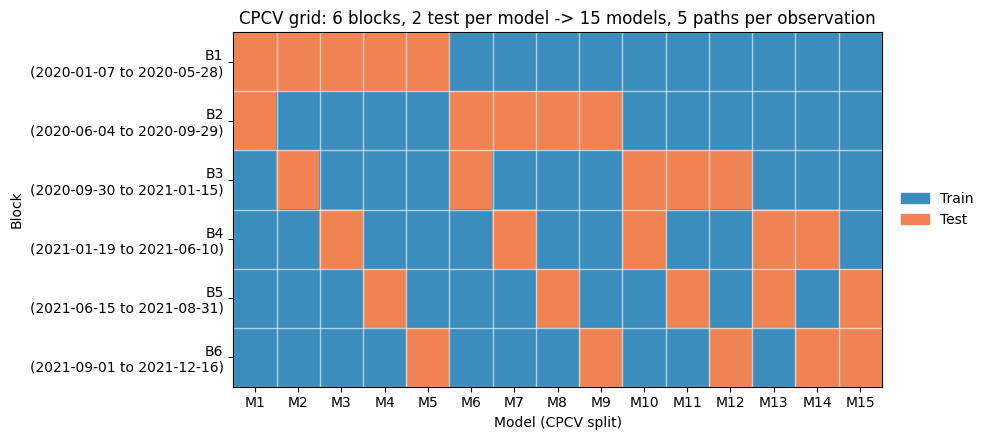

,split_id,test_block_ids,train_rows,test_rows,purged_rows,embargo_rows,removed_from_train
0,0,"(0, 1)",205,108,0,10,10
1,1,"(0, 2)",188,108,7,20,27
2,2,"(0, 3)",188,108,7,20,27
3,3,"(0, 4)",187,108,8,20,28
4,4,"(0, 5)",196,107,10,10,20
5,5,"(1, 2)",203,108,2,10,12
6,6,"(1, 3)",186,108,9,20,29
7,7,"(1, 4)",185,108,10,20,30
8,8,"(1, 5)",194,107,12,10,22
9,9,"(2, 3)",198,108,7,10,17


In [12]:
example = cpcv_examples[0]
example_data = example["data"]
example_splits = example["splits"]

assignment_matrix, block_info = cpcv_assignment_matrix(example_data, example_splits)

split_rows = []
for split in example_splits:
    counts = split_status_counts(example_data, split)
    split_rows.append({
        "split_id": split["split_id"],
        "test_block_ids": split["test_block_ids"],
        "train_rows": split["train_rows"],
        "test_rows": split["test_rows"],
        "purged_rows": counts.get("purged", 0),
        "embargo_rows": counts.get("embargo", 0),
        "removed_from_train": counts.get("purged", 0) + counts.get("embargo", 0),
    })

print(f"{example['instrument']} | {example['config_name']}")
print("Rows:", len(example_data))
print("Features:", len(example["feature_cols"]))
print("Embargo observations:", example["embargo_observations"])
print("CPCV matrix shape:", assignment_matrix.shape)

display(block_info)
plot_cpcv_grid(example_data, example_splits)
display(pd.DataFrame(split_rows))


## 12. Summarise Candidates

A candidate is one model family plus one hyperparameter setting plus one triple-barrier config. We rank candidates by mean CPCV AUC.


In [13]:
group_cols = ["instrument", "config_name", "model_name", "model_family", "penalty", "C", "l1_ratio"]

candidate_summary = (
    path_level_results
    .groupby(group_cols, dropna=False, as_index=False)
    .agg(
        mean_auc=("auc", "mean"),
        median_auc=("auc", "median"),
        std_auc=("auc", "std"),
        valid_auc_paths=("auc", lambda x: x.notna().sum()),
        mean_brier=("brier", "mean"),
        mean_log_loss=("log_loss", "mean"),
        mean_accuracy=("accuracy", "mean"),
        mean_precision=("precision", "mean"),
        mean_recall=("recall", "mean"),
        mean_f1=("f1", "mean"),
        median_trade_sharpe=("trade_sharpe", "median"),
        mean_trade_sharpe=("trade_sharpe", "mean"),
        total_trades=("trade_count", "sum"),
        avg_nonzero_coef_count=("nonzero_coef_count", "mean"),
        total_convergence_warnings=("convergence_warning_count", "sum"),
        total_runtime_warnings=("runtime_warning_count", "sum"),
        feature_count=("feature_count", "first"),
        label_rows=("label_rows", "first"),
        embargo_observations=("embargo_observations", "first"),
    )
)

min_valid_paths = 0.8 * candidate_summary["valid_auc_paths"].max()
candidate_summary = candidate_summary[candidate_summary["valid_auc_paths"] >= min_valid_paths].copy()

candidate_summary = candidate_summary.sort_values(
    ["instrument", "mean_auc", "std_auc", "median_trade_sharpe", "total_trades"],
    ascending=[True, False, True, False, False],
).reset_index(drop=True)

top5_by_auc = candidate_summary.head(5).copy()

TOP5_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
top5_by_auc.to_csv(TOP5_RESULTS_PATH, index=False)
top5_by_auc.to_csv(LOGISTIC_RESULTS_PATH, index=False)

best_by_instrument = candidate_summary.groupby("instrument", as_index=False, group_keys=False).head(1).reset_index(drop=True)
best_by_instrument_config = candidate_summary.groupby(["instrument", "config_name"], as_index=False, group_keys=False).head(1).reset_index(drop=True)

print("Saved top 5 AUC-ranked model combinations to:", TOP5_RESULTS_PATH)
print("Also saved clearer logistic-regression copy to:", LOGISTIC_RESULTS_PATH)

display(top5_by_auc)
display(candidate_summary.head(30))
display(best_by_instrument)


Saved top 5 AUC-ranked model combinations to: /Users/akshatg/Desktop/Imperial/Assessments/Term 3/systematic-strategies-with-machine-learning-Cw/results/linear_regression.csv
Also saved clearer logistic-regression copy to: /Users/akshatg/Desktop/Imperial/Assessments/Term 3/systematic-strategies-with-machine-learning-Cw/results/logistic_regression.csv


,instrument,config_name,model_name,model_family,penalty,C,l1_ratio,mean_auc,median_auc,std_auc,valid_auc_paths,mean_brier,mean_log_loss,mean_accuracy,mean_precision,mean_recall,mean_f1,median_trade_sharpe,mean_trade_sharpe,total_trades,avg_nonzero_coef_count,total_convergence_warnings,total_runtime_warnings,feature_count,label_rows,embargo_observations
0,cl1s,ewma_10d_tp2_sl2,l2_C0.1,l2_logistic,l2,0.1,NaN,0.636801,0.608947,0.136542,15,0.280703,0.861422,0.586720,0.432940,0.535421,0.445829,0.184562,0.222602,712,137.933333,0,0,138,323,10
1,cl1s,ewma_10d_tp2_sl2,l2_C1,l2_logistic,l2,1.0,NaN,0.635151,0.632911,0.162642,15,0.341028,1.523265,0.582953,0.412329,0.568105,0.450401,0.181324,0.167721,754,137.933333,0,0,138,323,10
2,cl1s,ewma_10d_tp2_sl2,elastic_C1_l1r0.5,elastic_net_logistic,elasticnet,1.0,0.5,0.626200,0.621212,0.163215,15,0.333941,1.418127,0.578562,0.401687,0.530700,0.431518,0.188650,0.176138,717,68.733333,0,0,138,323,10
3,cl1s,ewma_10d_tp2_sl2,elastic_C0.1_l1r0.5,elastic_net_logistic,elasticnet,0.1,0.5,0.604684,0.627273,0.145644,15,0.264052,0.746173,0.572540,0.430898,0.447385,0.391112,0.306239,0.316188,597,24.866667,0,0,138,323,10
4,cl1s,ewma_10d_tp2_sl2,l1_C1,l1_logistic,l1,1.0,NaN,0.602136,0.600699,0.178650,15,0.361229,1.605374,0.564278,0.387295,0.522138,0.415530,0.162747,0.188657,724,36.066667,0,0,138,323,10


,instrument,config_name,model_name,model_family,penalty,C,l1_ratio,mean_auc,median_auc,std_auc,valid_auc_paths,mean_brier,mean_log_loss,mean_accuracy,mean_precision,mean_recall,mean_f1,median_trade_sharpe,mean_trade_sharpe,total_trades,avg_nonzero_coef_count,total_convergence_warnings,total_runtime_warnings,feature_count,label_rows,embargo_observations
0,cl1s,ewma_10d_tp2_sl2,l2_C0.1,l2_logistic,l2,0.1,NaN,0.636801,0.608947,0.136542,15,0.280703,0.861422,0.586720,0.432940,0.535421,0.445829,0.184562,0.222602,712,137.933333,0,0,138,323,10
1,cl1s,ewma_10d_tp2_sl2,l2_C1,l2_logistic,l2,1.0,NaN,0.635151,0.632911,0.162642,15,0.341028,1.523265,0.582953,0.412329,0.568105,0.450401,0.181324,0.167721,754,137.933333,0,0,138,323,10
2,cl1s,ewma_10d_tp2_sl2,elastic_C1_l1r0.5,elastic_net_logistic,elasticnet,1.0,0.5,0.626200,0.621212,0.163215,15,0.333941,1.418127,0.578562,0.401687,0.530700,0.431518,0.188650,0.176138,717,68.733333,0,0,138,323,10
3,cl1s,ewma_10d_tp2_sl2,elastic_C0.1_l1r0.5,elastic_net_logistic,elasticnet,0.1,0.5,0.604684,0.627273,0.145644,15,0.264052,0.746173,0.572540,0.430898,0.447385,0.391112,0.306239,0.316188,597,24.866667,0,0,138,323,10
4,cl1s,ewma_10d_tp2_sl2,l1_C1,l1_logistic,l1,1.0,NaN,0.602136,0.600699,0.178650,15,0.361229,1.605374,0.564278,0.387295,0.522138,0.415530,0.162747,0.188657,724,36.066667,0,0,138,323,10
5,cl1s,ewma_10d_tp2_sl2,l1_C0.1,l1_logistic,l1,0.1,NaN,0.575124,0.557545,0.143002,15,0.264020,0.733390,0.542898,0.417244,0.480064,0.394597,0.458732,0.243574,693,8.733333,0,0,138,323,10


,instrument,config_name,model_name,model_family,penalty,C,l1_ratio,mean_auc,median_auc,std_auc,valid_auc_paths,mean_brier,mean_log_loss,mean_accuracy,mean_precision,mean_recall,mean_f1,median_trade_sharpe,mean_trade_sharpe,total_trades,avg_nonzero_coef_count,total_convergence_warnings,total_runtime_warnings,feature_count,label_rows,embargo_observations
0,cl1s,ewma_10d_tp2_sl2,l2_C0.1,l2_logistic,l2,0.1,NaN,0.636801,0.608947,0.136542,15,0.280703,0.861422,0.58672,0.43294,0.535421,0.445829,0.184562,0.222602,712,137.933333,0,0,138,323,10


## 13. Fit Final Selected Models

After CPCV chooses the best candidate per instrument, fit that selected model on all pre-2022 labelled rows and inspect the largest coefficients.


In [14]:
final_models = {}
coefficient_tables = {}

for _, selected in best_by_instrument.iterrows():
    label_row = label_files[
        (label_files["instrument"] == selected["instrument"])
        & (label_files["config_name"] == selected["config_name"])
    ].iloc[0]
    spec = next(s for s in model_specs if s["model_name"] == selected["model_name"])

    data, feature_cols, embargo_observations = make_model_data(label_row)
    y = data["metalabel"].astype(int)

    final_features, _ = clip_with_train_bounds(data[feature_cols], data[feature_cols])

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()
    x = imputer.fit_transform(final_features)
    x = scaler.fit_transform(x)

    model = LogisticRegression(**spec["params"])
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        warnings.simplefilter("always", RuntimeWarning)
        model.fit(x, y)

    coefficients = pd.DataFrame({"feature": feature_cols, "coefficient": model.coef_.ravel()})
    coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
    coefficients = coefficients.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

    final_models[selected["instrument"]] = {
        "model": model,
        "imputer": imputer,
        "scaler": scaler,
        "feature_cols": feature_cols,
        "selected_config": selected.to_dict(),
    }
    coefficient_tables[selected["instrument"]] = coefficients

    print(f"{selected['instrument']} | {selected['config_name']} | {selected['model_name']}")
    print("Rows:", len(data), "Features:", len(feature_cols), "Embargo:", embargo_observations)
    print("Final fit warnings:", len(caught))
    print("Top positive coefficients")
    display(coefficients.sort_values("coefficient", ascending=False).head(15))
    print("Top negative coefficients")
    display(coefficients.sort_values("coefficient", ascending=True).head(15))


cl1s | ewma_10d_tp2_sl2 | l2_C0.1
Rows: 323 Features: 138 Embargo: 10
Final fit warnings: 0
Top positive coefficients


,feature,coefficient,abs_coefficient
0,vol_ratio_63_126d,0.649874,0.649874
1,mom_sign_252d,0.513870,0.513870
2,mom_sign_20d,0.420523,0.420523
4,bb_width_zscore,0.395845,0.395845
7,donchian_pos_252d,0.300084,0.300084
8,macd_zscore,0.291770,0.291770
12,hmm_market_calm_positive,0.274485,0.274485
14,donchian_pos_20d,0.257289,0.257289
17,ret_spread_5_20,0.239219,0.239219
21,macd_hist,0.222174,0.222174


Top negative coefficients


,feature,coefficient,abs_coefficient
3,mom_sign_63d,-0.397043,0.397043
5,uo,-0.389431,0.389431
6,sma50_slope,-0.327893,0.327893
9,zscore_63d,-0.287115,0.287115
10,ret_126d,-0.286818,0.286818
11,rsi_7d,-0.277606,0.277606
13,signal_x_hmm_prob_high_or_extreme_vol,-0.262158,0.262158
15,ret_63d,-0.252206,0.252206
16,rsi_14d,-0.247395,0.247395
18,mfi_14d,-0.236947,0.236947


## 14. Optional Save

`results/linear_regression.csv` is always written because it was requested as the top-5 output. The extra model artifacts below are only saved when `SAVE_OUTPUTS = True`.


In [15]:
if SAVE_OUTPUTS:
    import joblib

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    path_level_results.to_csv(OUTPUT_DIR / "path_level_results.csv", index=False)
    candidate_summary.to_csv(OUTPUT_DIR / "candidate_summary.csv", index=False)
    best_by_instrument.to_csv(OUTPUT_DIR / "selected_configs.csv", index=False)
    best_by_instrument_config.to_csv(OUTPUT_DIR / "best_by_instrument_config.csv", index=False)

    for instrument, model_bundle in final_models.items():
        joblib.dump(model_bundle, OUTPUT_DIR / f"{instrument}_final_logistic_model.joblib")
        coefficient_tables[instrument].to_csv(OUTPUT_DIR / f"{instrument}_coefficients.csv", index=False)

    print("Saved outputs to", OUTPUT_DIR)
else:
    print("SAVE_OUTPUTS is False, so only the top-5 CSV files were written.")


SAVE_OUTPUTS is False, so only the top-5 CSV files were written.
